# Ohlcv 1m Split-Normalized - Inspection Notebook `v0_1`

## Rol

Este notebook no abre una auditoría nueva.

Su función es hacer **navegable y verificable** la auditoría ya cerrada de `ohlcv_1m_split_normalized`, uniendo:

- contrato y semántica;
- piloto de precio `raw vs split_normalized`;
- consumidor mínimo real `intraday_regime_features`;
- y veredicto final para inspector.

La pregunta auditada es concreta:

- ¿los splits del piloto están resueltos de forma semánticamente correcta,
- visualmente inspeccionable,
- y downstream-válida en un consumidor mínimo real?

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

PROJECT_ROOT = Path(r'C:\TSIS_Data\01_TSIS_backtest_SmallCaps')
DOSSIER_DIR = PROJECT_ROOT / '01_foundations' / 'inspection_dossiers' / '1m_split_normalized'
IMAGES_DIR = DOSSIER_DIR / 'images'
MANIFEST_PATH = PROJECT_ROOT / '01_foundations' / 'dataset_registry' / '1m' / 'ohlcv_1m_split_normalized_pilot_manifest_v0_2.csv'
MATERIALIZATION_SUMMARY = Path(r'E:\TSIS\data\ohlcv_1m_split_normalized\_split_normalized_materialization_summary.csv')
FEATURES_SUMMARY = Path(r'E:\TSIS\data\intraday_regime_features\_intraday_regime_features_materialization_summary.csv')
manifest = pd.read_csv(MANIFEST_PATH)
mat = pd.read_csv(MATERIALIZATION_SUMMARY)
feat = pd.read_csv(FEATURES_SUMMARY)
manifest

,ticker,year,month,event_type,event_date,role,split_from,split_to,rationale
0,BXRX,2022,12,reverse_split,2022-12-01,reverse_split,40,1,reverse split reciente con cobertura mensual c...
1,COSM,2022,12,reverse_split,2022-12-16,reverse_split,25,1,reverse split reciente con buena densidad intr...
2,CEI,2022,12,reverse_split,2022-12-21,reverse_split,50,1,reverse split reciente con cobertura fuerte en...
3,BNGO,2025,1,reverse_split,2025-01-27,reverse_split,60,1,reverse split reciente y muy claro para valida...
4,EFSH,2025,1,forward_split,2025-01-10,forward_split,1,2,forward split simple y reciente con buena cobe...
5,SAVA,2023,12,forward_split,2023-12-21,forward_split,10,14,forward split reciente con magnitud visible y ...
6,PD,2006,3,forward_split,2006-03-13,forward_split,1,2,forward split historico temprano para no sesga...
7,LIVE,2014,2,forward_split,2014-02-12,forward_split,1,3,forward split intermedio con cobertura estable...
8,BXRX,2022,11,none,NaN,control,1,1,control pre-evento del mismo ticker sin split ...
9,BNGO,2025,2,none,NaN,control,1,1,control post-evento del mismo ticker sin split...


## 1. Qué responde esta tabla

### Que muestra

- El universo exacto del piloto de `1m_split_normalized`.
- Qué casos son `reverse split`, cuáles `forward split` y cuáles son controles.

### Responde

- Si estamos auditando una muestra semánticamente suficiente.
- Si el piloto cubre eventos positivos y controles.

### No responde

- No demuestra por sí sola que la capa esté bien.
- Solo fija el perímetro de auditoría.

### Consecuencia

- Evita discutir semántica en abstracto sin saber exactamente sobre qué casos se hizo la prueba.

In [2]:
display(Markdown('## 2. Resumen operativo de materialización'))
display(mat[['ticker','year','month','role','event_type','rows_written','split_non1_rows']])

mat_eval = mat.copy()
mat_eval['pct_split_non1'] = (mat_eval['split_non1_rows'] / mat_eval['rows_written'] * 100).round(2)
display(Markdown('### Lectura cuantitativa rápida'))
display(mat_eval[['ticker','year','month','role','pct_split_non1']])

## 2. Resumen operativo de materialización

,ticker,year,month,role,event_type,rows_written,split_non1_rows
0,BXRX,2022,12,reverse_split,reverse_split,7424,0
1,COSM,2022,12,reverse_split,reverse_split,16986,9929
2,CEI,2022,12,reverse_split,reverse_split,15660,10956
3,BNGO,2025,1,reverse_split,reverse_split,10560,9256
4,EFSH,2025,1,forward_split,forward_split,6328,2430
5,SAVA,2023,12,forward_split,forward_split,7760,5393
6,PD,2006,3,forward_split,forward_split,9345,3200
7,LIVE,2014,2,forward_split,forward_split,7038,7038
8,BXRX,2022,11,control,none,3801,3801
9,BNGO,2025,2,control,none,2724,0


### Lectura cuantitativa rápida

,ticker,year,month,role,pct_split_non1
0,BXRX,2022,12,reverse_split,0.00
1,COSM,2022,12,reverse_split,58.45
2,CEI,2022,12,reverse_split,69.96
3,BNGO,2025,1,reverse_split,87.65
4,EFSH,2025,1,forward_split,38.40
5,SAVA,2023,12,forward_split,69.50
6,PD,2006,3,forward_split,34.24
7,LIVE,2014,2,forward_split,100.00
8,BXRX,2022,11,control,100.00
9,BNGO,2025,2,control,0.00


## 2. Cómo leer este resumen

### Que muestra

- Cuánta masa de cada `ticker-month` quedó realmente reescalada.

### Responde

- Si el comportamiento del factor es coherente con la posición temporal del split dentro del mes.

### Lectura técnica

- Un `0%` no significa error: puede describir un split en el primer día del mes observado.
- Un `100%` tampoco significa error: puede describir un control pre-evento o un mes totalmente anterior al cambio de escala.
- Lo importante no es que todos los meses “se parezcan”, sino que cada patrón tenga sentido temporal.

### Consecuencia

- Esta tabla permite detectar si la capa estaría aplicando una regla superficial. El hecho de que existan patrones muy distintos y todos sean coherentes es precisamente una señal de semántica correcta.

In [3]:
display(Markdown('## 3. Resumen operativo del consumidor mínimo'))
display(feat)
display(Markdown('### Qué significa'))
display(Markdown('- Esta tabla solo prueba que el consumidor se materializó sobre el universo piloto disponible. La validación semántica fuerte viene al comparar `raw` vs `split_normalized` en sus features cross-session.'))

## 3. Resumen operativo del consumidor mínimo

,ticker,files_seen,years_written,days_written
0,BNGO,2,1,47
1,BXRX,2,1,48
2,CEI,1,1,26
3,COSM,1,1,26
4,EFSH,1,1,26
5,LIVE,1,1,23
6,PD,1,1,23
7,SAVA,1,1,24


### Qué significa

- Esta tabla solo prueba que el consumidor se materializó sobre el universo piloto disponible. La validación semántica fuerte viene al comparar `raw` vs `split_normalized` en sus features cross-session.

In [4]:
semantic_summary = pd.DataFrame([
    {'ticker':'BNGO','month':'2025-01','role':'reverse_split','max_abs_gap_diff_pct':5183.28,'max_abs_ret3_diff_pct':4732.34,'max_abs_range_center_diff_pct':5054.43},
    {'ticker':'CEI','month':'2022-12','role':'reverse_split','max_abs_gap_diff_pct':4900.00,'max_abs_ret3_diff_pct':4694.29,'max_abs_range_center_diff_pct':4337.15},
    {'ticker':'BXRX','month':'2022-12','role':'reverse_split','max_abs_gap_diff_pct':3897.11,'max_abs_ret3_diff_pct':4175.48,'max_abs_range_center_diff_pct':3340.38},
    {'ticker':'COSM','month':'2022-12','role':'reverse_split','max_abs_gap_diff_pct':2450.70,'max_abs_ret3_diff_pct':4507.04,'max_abs_range_center_diff_pct':1969.81},
    {'ticker':'EFSH','month':'2025-01','role':'forward_split','max_abs_gap_diff_pct':111.76,'max_abs_ret3_diff_pct':99.33,'max_abs_range_center_diff_pct':110.25},
    {'ticker':'LIVE','month':'2014-02','role':'forward_split','max_abs_gap_diff_pct':66.67,'max_abs_ret3_diff_pct':119.08,'max_abs_range_center_diff_pct':66.47},
    {'ticker':'PD','month':'2006-03','role':'forward_split','max_abs_gap_diff_pct':49.81,'max_abs_ret3_diff_pct':52.38,'max_abs_range_center_diff_pct':51.01},
    {'ticker':'SAVA','month':'2023-12','role':'forward_split','max_abs_gap_diff_pct':28.49,'max_abs_ret3_diff_pct':35.45,'max_abs_range_center_diff_pct':28.21},
    {'ticker':'BXRX','month':'2022-11','role':'control','max_abs_gap_diff_pct':0.0,'max_abs_ret3_diff_pct':0.0,'max_abs_range_center_diff_pct':0.0},
    {'ticker':'BNGO','month':'2025-02','role':'control','max_abs_gap_diff_pct':0.0,'max_abs_ret3_diff_pct':0.0,'max_abs_range_center_diff_pct':0.0},
])
display(Markdown('## 4. Resumen semántico del consumidor'))
display(semantic_summary.sort_values(['max_abs_gap_diff_pct'], ascending=False).reset_index(drop=True))

## 4. Resumen semántico del consumidor

,ticker,month,role,max_abs_gap_diff_pct,max_abs_ret3_diff_pct,max_abs_range_center_diff_pct
0,BNGO,2025-01,reverse_split,5183.28,4732.34,5054.43
1,CEI,2022-12,reverse_split,4900.00,4694.29,4337.15
2,BXRX,2022-12,reverse_split,3897.11,4175.48,3340.38
3,COSM,2022-12,reverse_split,2450.70,4507.04,1969.81
4,EFSH,2025-01,forward_split,111.76,99.33,110.25
5,LIVE,2014-02,forward_split,66.67,119.08,66.47
6,PD,2006-03,forward_split,49.81,52.38,51.01
7,SAVA,2023-12,forward_split,28.49,35.45,28.21
8,BXRX,2022-11,control,0.00,0.00,0.00
9,BNGO,2025-02,control,0.00,0.00,0.00


## 4. Cómo leer esta tabla del consumidor

### Que muestra

- La divergencia real entre calcular las mismas features cross-session con `raw` y con `split_normalized`.

### Responde

- Si `1m_split_normalized` cambia de verdad un uso downstream sensible a splits.

### Lectura técnica

- Los reverse splits fuertes enseñan contaminaciones monstruosas bajo `raw`, de miles por ciento.
- Los forward splits también pueden deformar materialmente el gap y la memoria multi-sesión.
- Los controles a `0.00%` son tan importantes como los positivos fuertes: prueban que la corrección no se inventa donde no toca.

### Consecuencia

- Aquí es donde la auditoría deja de ser solo visual sobre precios y se convierte en validación de un uso real.

## Caso positivo fuerte | BNGO 2025-01

### Que muestra

- Comparación visual `raw` vs `split_normalized` en el caso elegido.

### Responde

- Si el comportamiento del factor y de la serie es coherente con el tipo de caso.


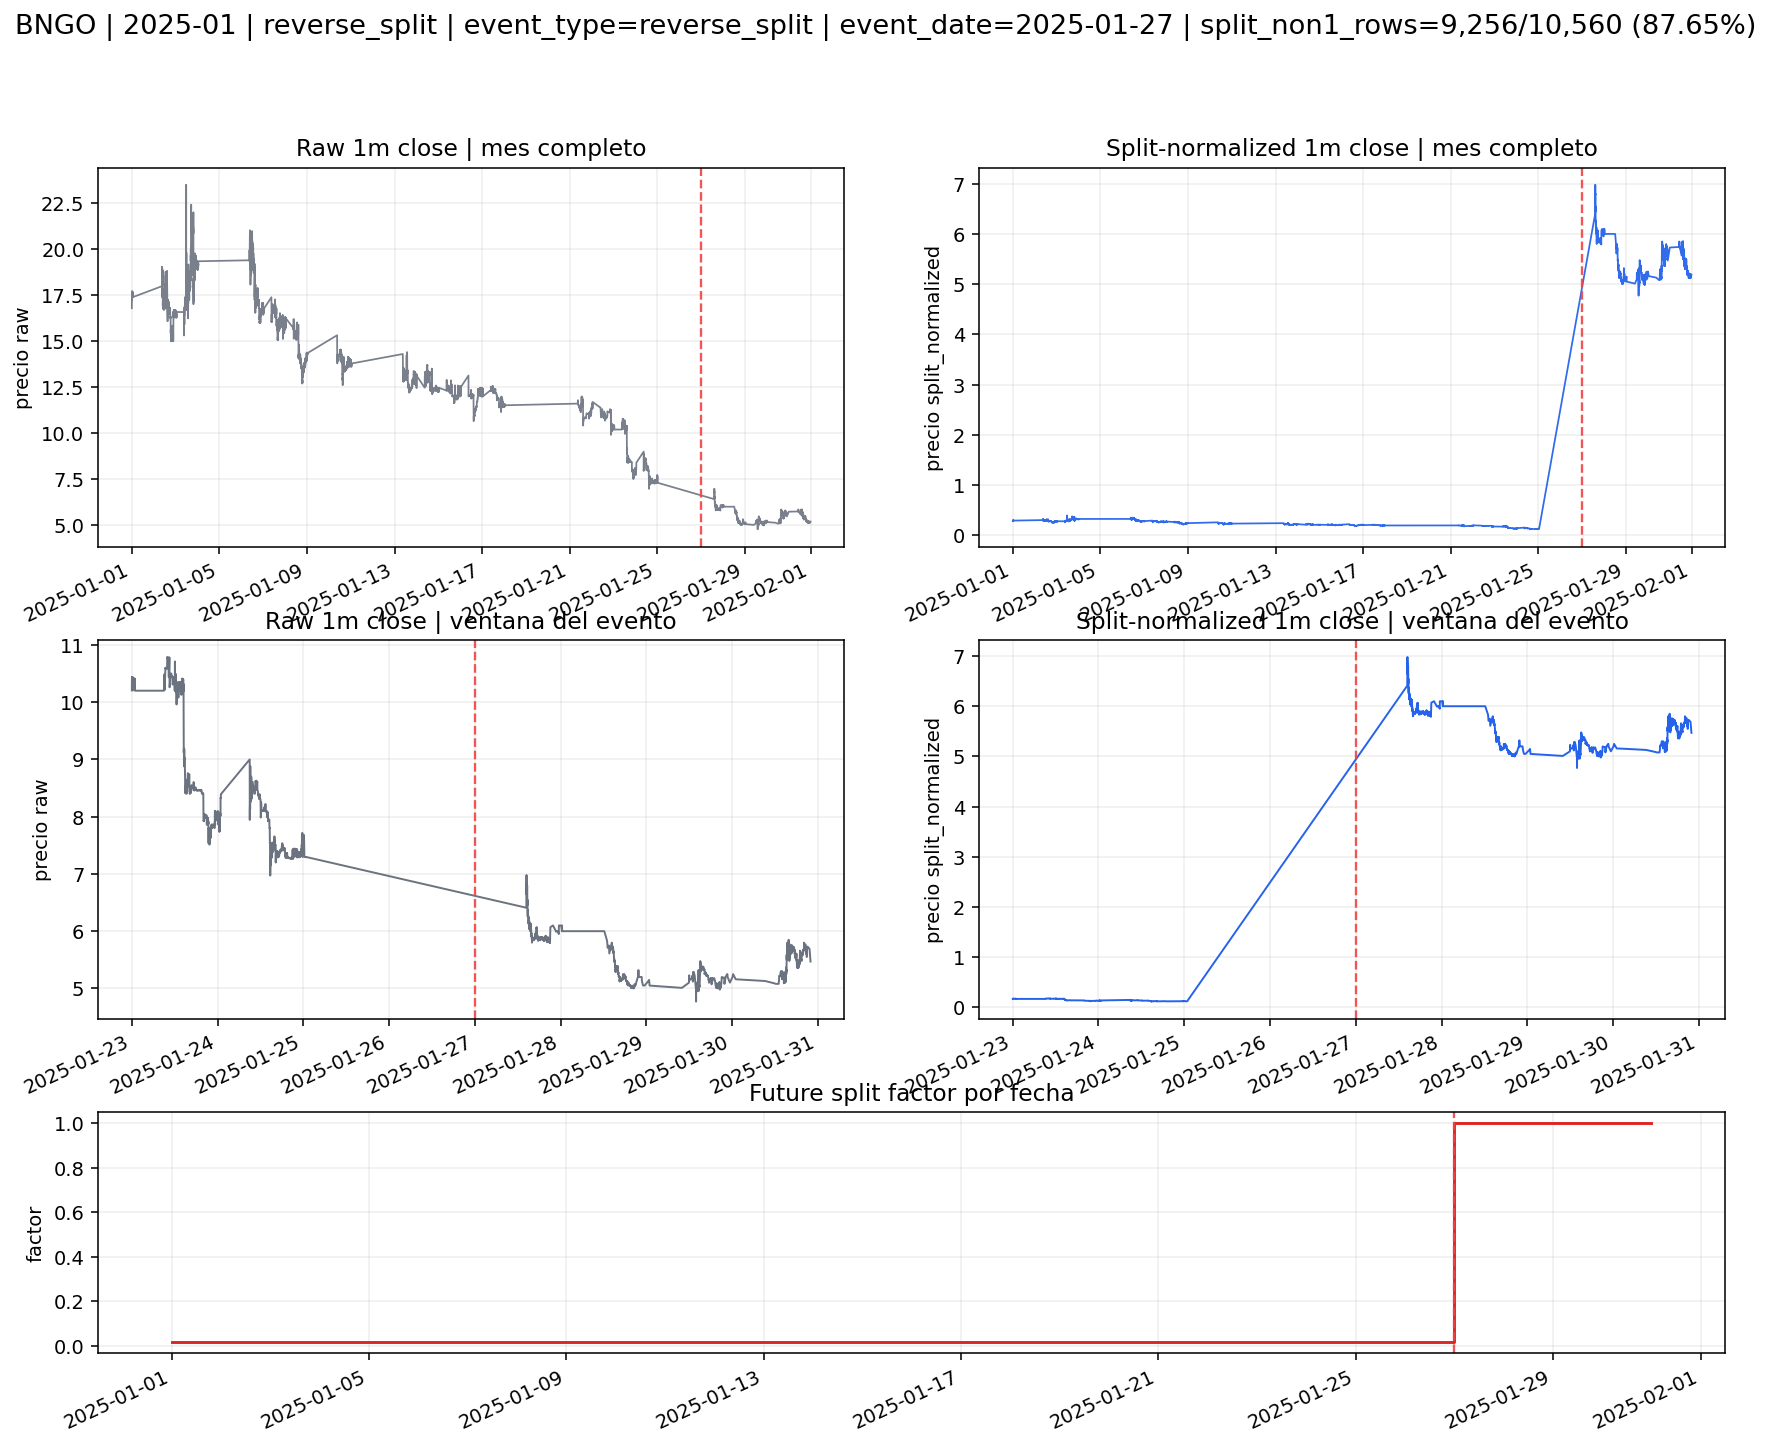

In [5]:
display(Image(filename=str(IMAGES_DIR / 'BNGO_2025_01.png')))

## Caso positivo fuerte | CEI 2022-12

### Que muestra

- Comparación visual `raw` vs `split_normalized` en el caso elegido.

### Responde

- Si el comportamiento del factor y de la serie es coherente con el tipo de caso.


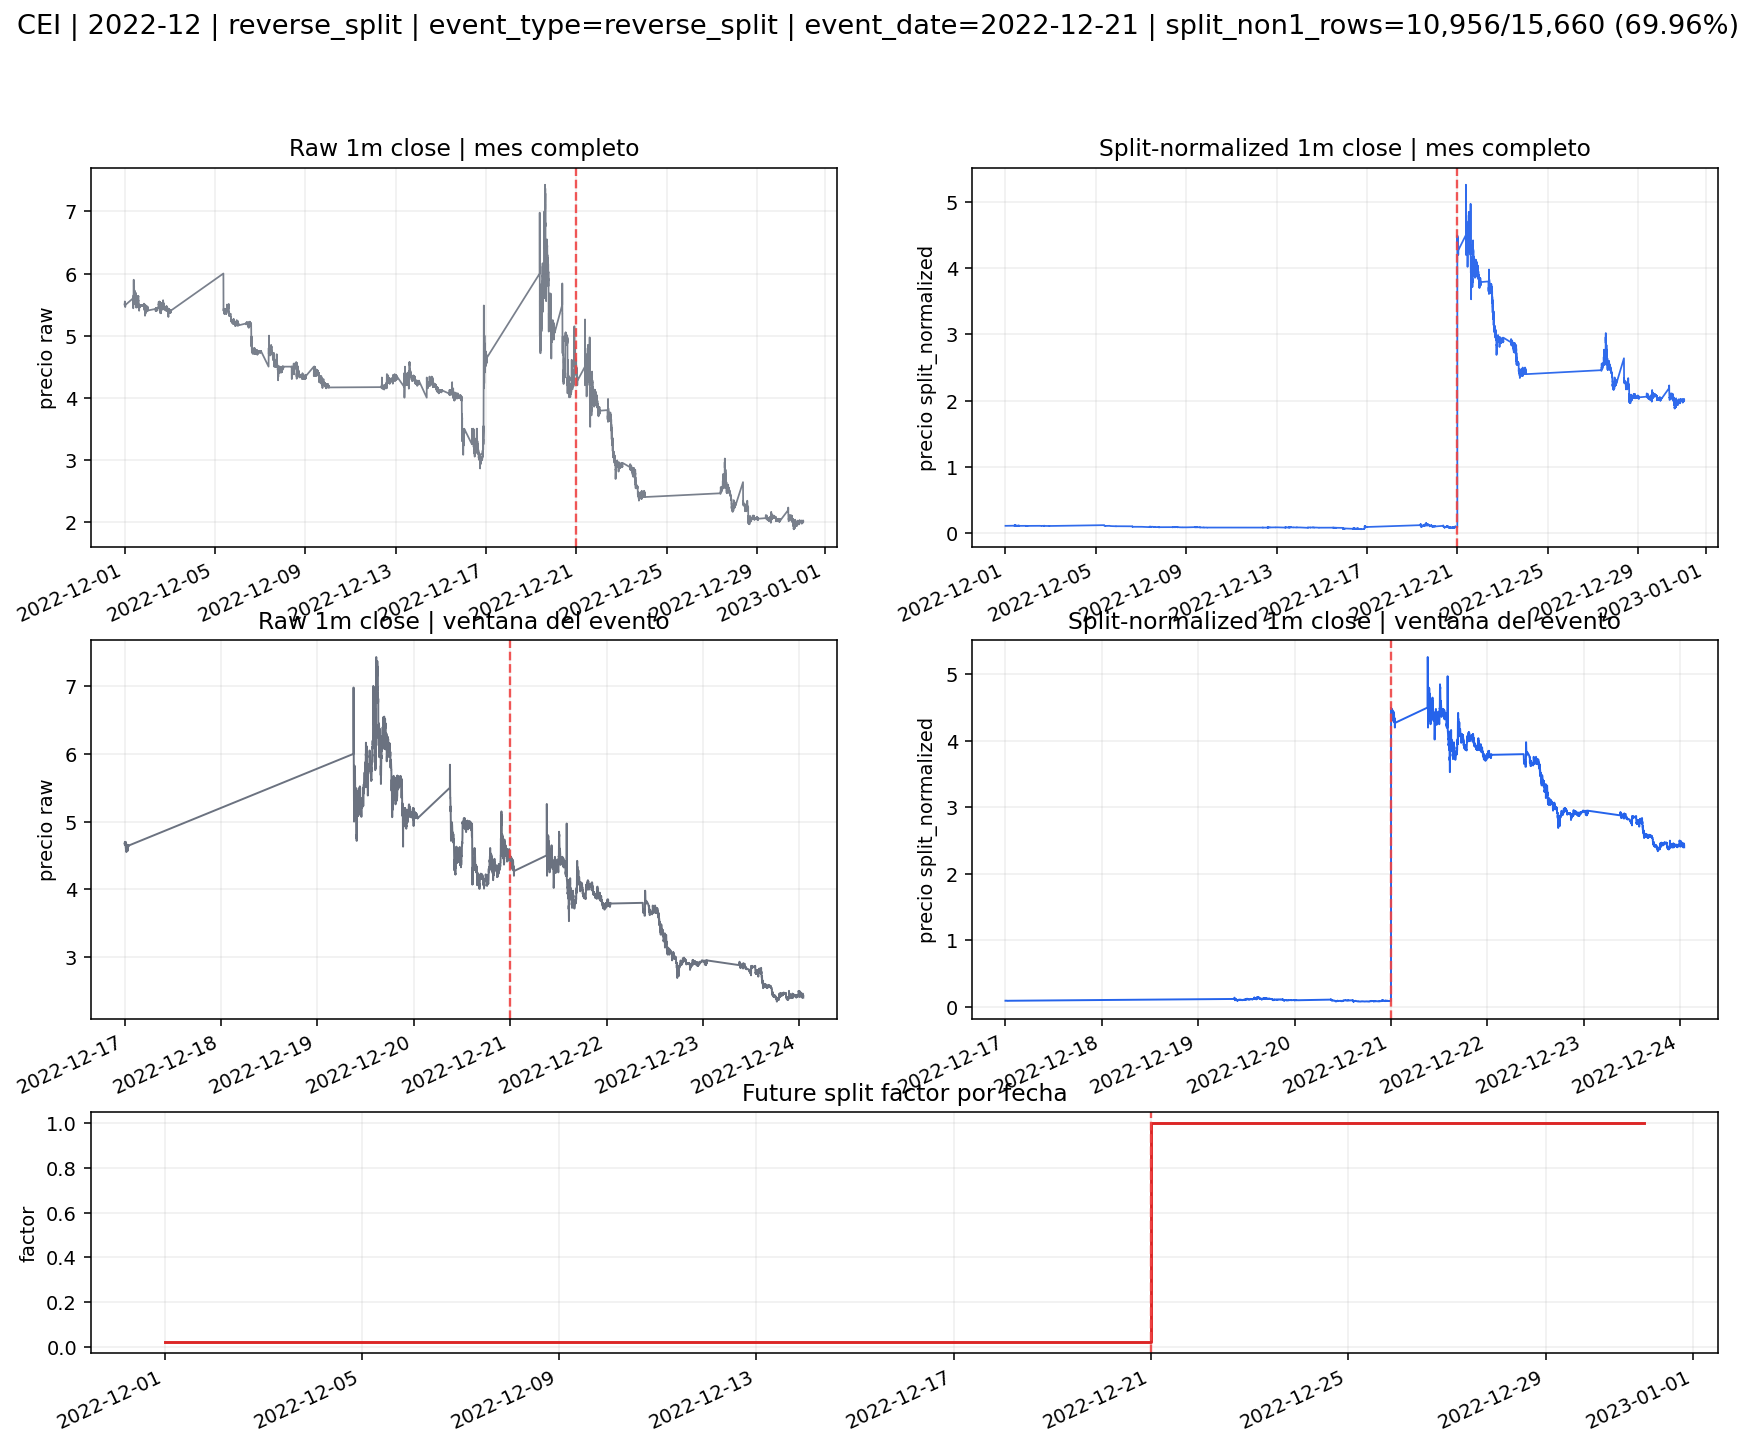

In [6]:
display(Image(filename=str(IMAGES_DIR / 'CEI_2022_12.png')))

## Control pre-evento | BXRX 2022-11

### Que muestra

- Comparación visual `raw` vs `split_normalized` en el caso elegido.

### Responde

- Si el comportamiento del factor y de la serie es coherente con el tipo de caso.


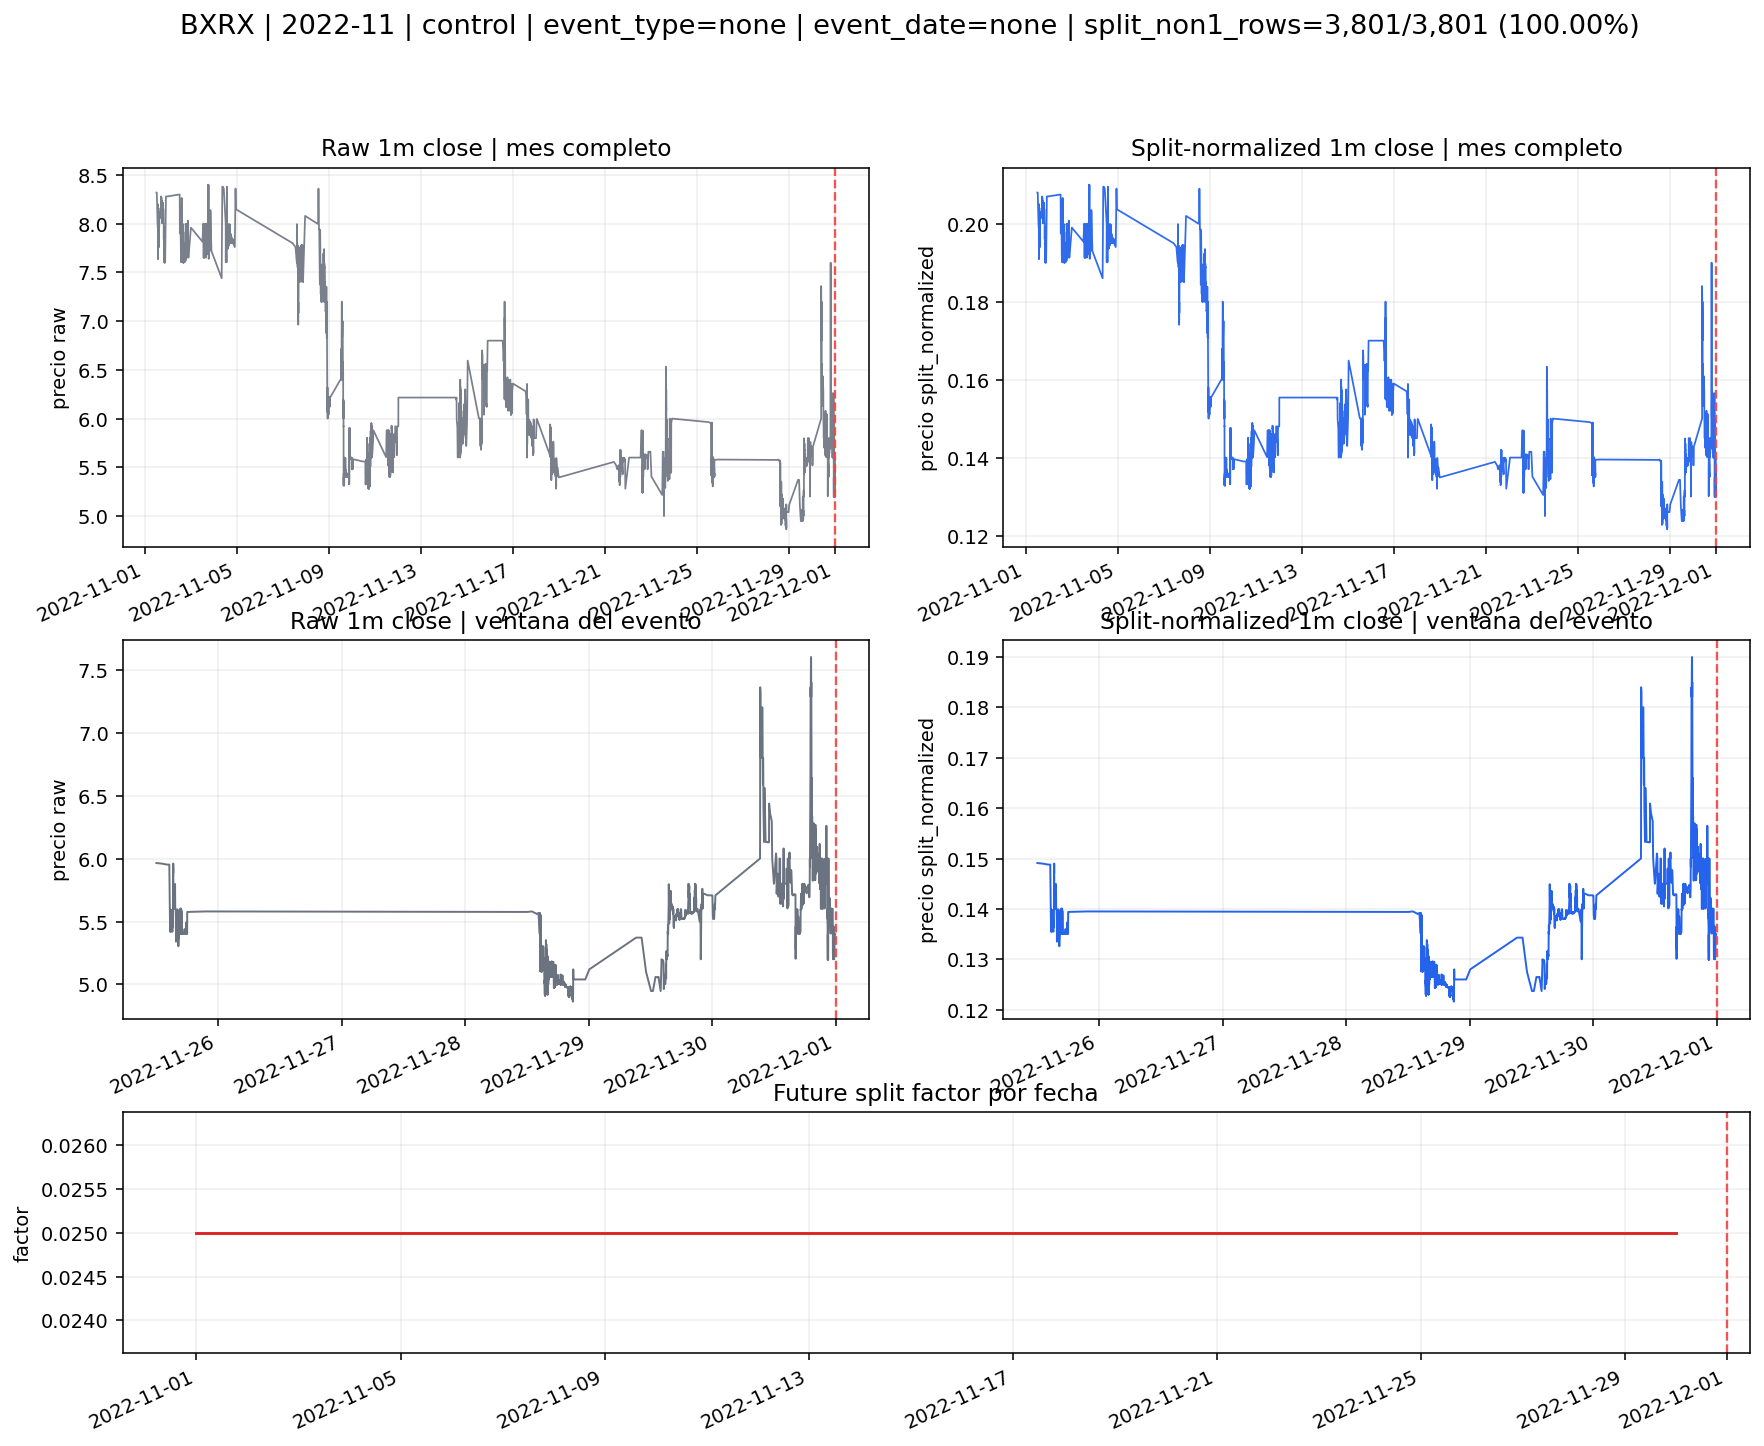

In [7]:
display(Image(filename=str(IMAGES_DIR / 'BXRX_2022_11.png')))

## Control post-evento | BNGO 2025-02

### Que muestra

- Comparación visual `raw` vs `split_normalized` en el caso elegido.

### Responde

- Si el comportamiento del factor y de la serie es coherente con el tipo de caso.


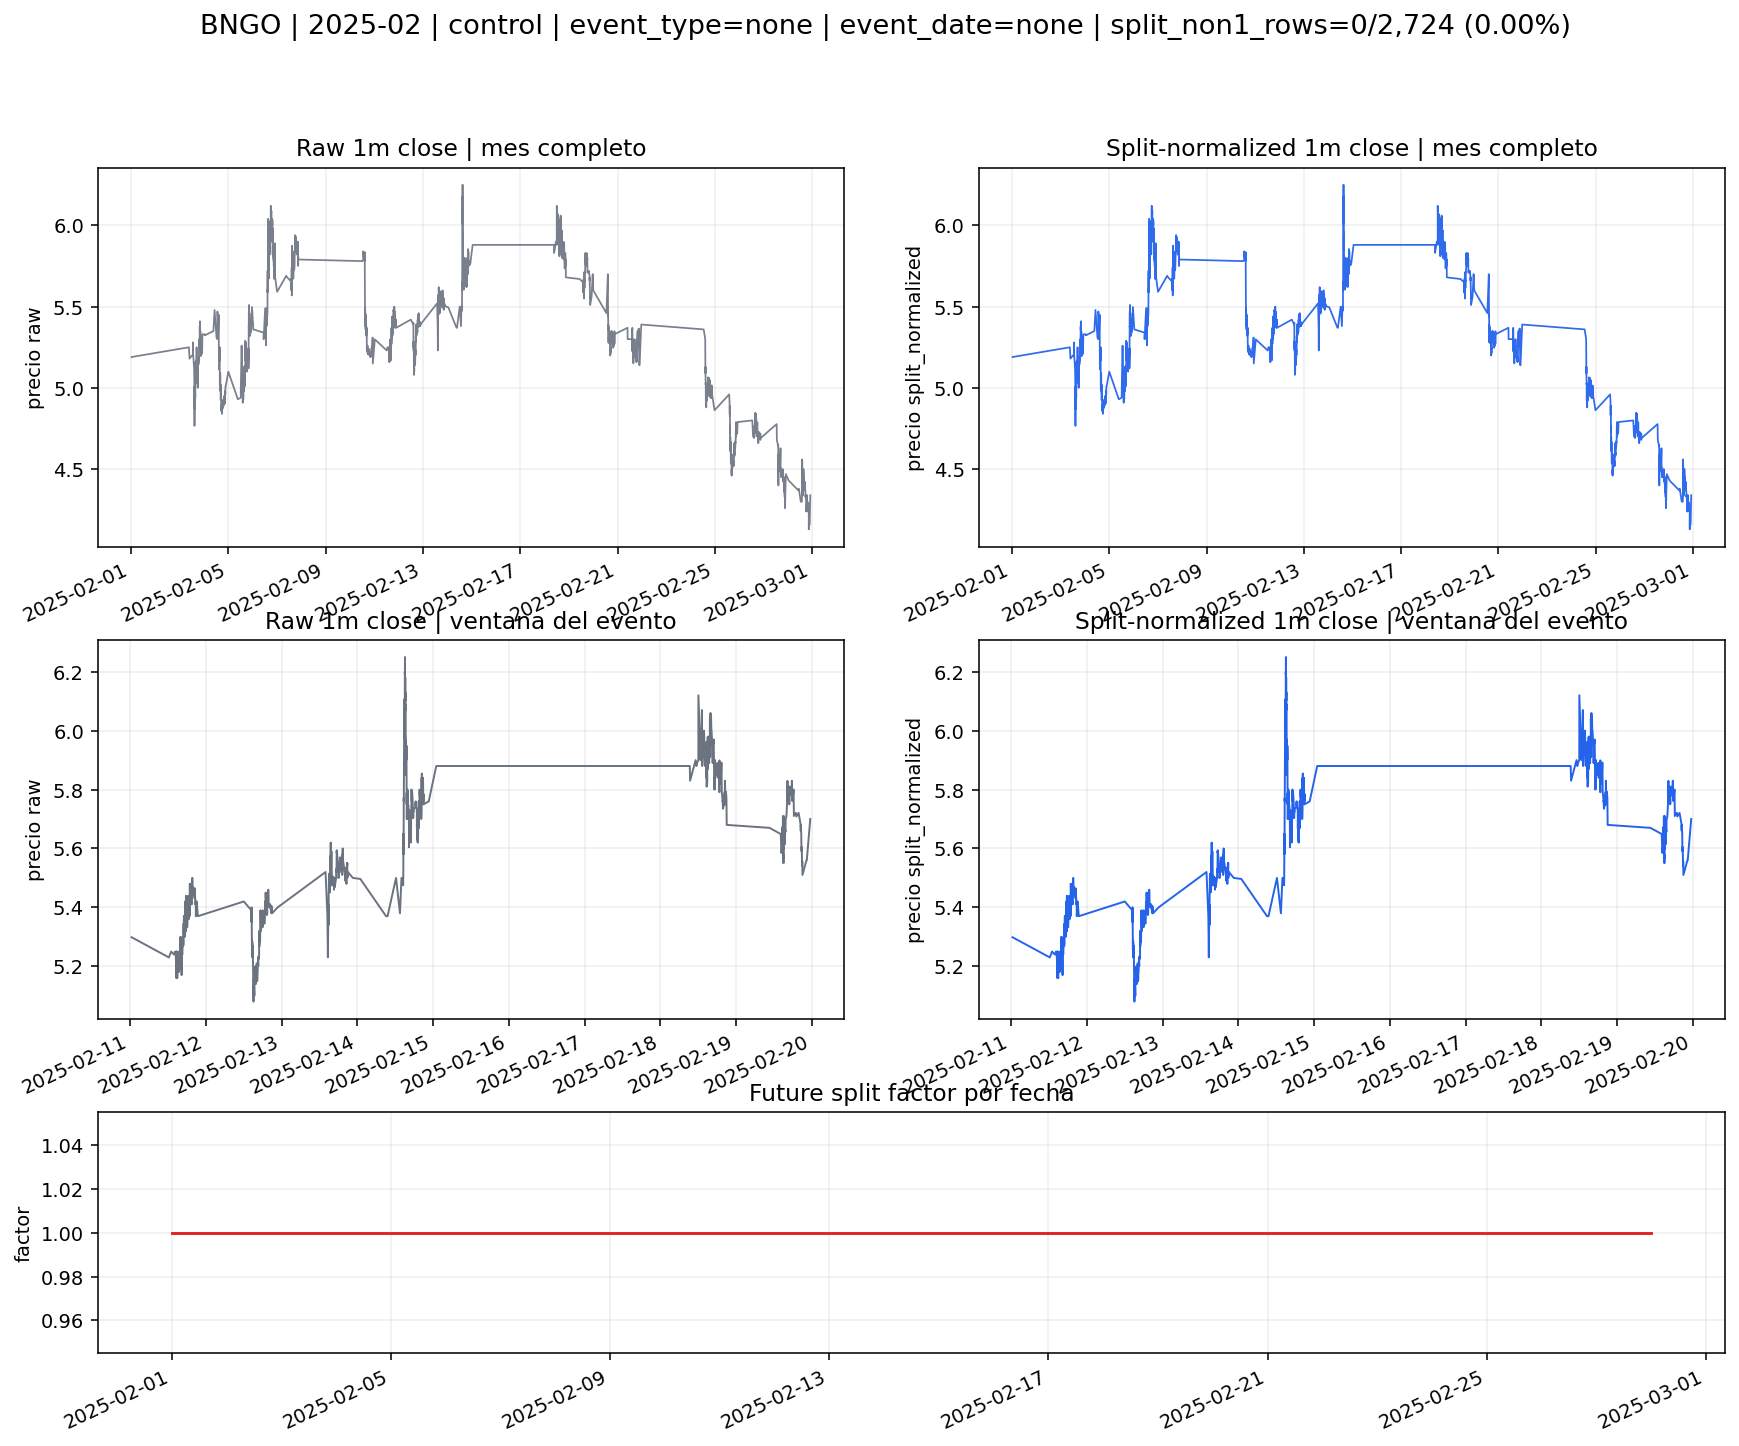

In [8]:
display(Image(filename=str(IMAGES_DIR / 'BNGO_2025_02.png')))

## 5. Veredicto final para inspector

### Que ya puede afirmarse

- La semántica de `ohlcv_1m_split_normalized` está bien definida.
- El piloto de precio la respeta en patrones positivos y controles.
- Un consumidor mínimo real deja de producir falsos shocks cross-session cuando usa la vista correcta.

### Que no debe afirmarse todavía

- No es una promoción full-universe cerrada.
- No es el final de toda la auditoría de `1m` para cualquier consumidor futuro.

### Conclusión prudente

- En el perímetro inspeccionado, los casos de split del piloto quedan semánticamente bien resueltos, visualmente auditados y downstream-válidos en un consumidor mínimo real.